# Bnpyro — Tutorial

**Bnpyro** is a Python library that compiles probabilistic programs into exact **Bayesian Networks** (BNs), using [pyAgrum](https://agrum.gitlab.io/) for BN structure and inference.

It implements the formal framework of the **λ!-calculus** from Faggian, Pautasso & Vanoni (POPL 2024):

| Bnpyro syntax | λ!-calculus |
|---|---|
| `bn.sample("x", Bernoulli(p))` | `let x = sample_d` |
| `bn.sample("x", bn.where(pa, ...))` | `let x = case⟨pa⟩` |
| `bn.plate("f", dist)` | `let f = !t` |
| `f()` | `der f` |
| `bn.recurse("x", fn, N)` | `fix f N` |

---

## Installation

```bash
pip install pyagrum scipy matplotlib graphviz
```

Also install the graphviz binaries: https://graphviz.org/download/

In [47]:
import sys, os
if os.path.basename(os.getcwd()) != 'src':
    sys.path.insert(0, 'src')

import matplotlib.pyplot as plt
from Bnpyro import BNppl, BNPlate, MIDPOINT, INTEGRATION
from distributions import Bernoulli, Categorical, Normal, Uniform

## 1. Classic BN — Rain → Wet

The simplest case: two Boolean variables linked by a conditional probability table (CPT).

```
Rain  →  Wet
P(Rain=T)         = 0.5
P(Wet=T | Rain=T) = 0.8
P(Wet=T | Rain=F) = 0.2
```

With a symmetric prior, the posterior is analytically exact — no rounding:

$$P(\text{Rain}=T \mid \text{Wet}=T) = \frac{0.8 \times 0.5}{0.8 \times 0.5 + 0.2 \times 0.5} = \frac{0.8}{1.0} = 0.8$$

`bn.where(condition, p_true, p_false)` encodes the conditional CPT.  
Corresponds to `let wet = case⟨rain⟩` in λ!-calculus.

In [48]:
bn1  = BNppl(name='RainWet')
rain = bn1.sample('rain', Bernoulli(0.5))
wet  = bn1.sample('wet',  bn1.where(rain, 0.8, 0.2))

bn1.compile()
bn1.show()


BN compiled : 2 nodes, 1 arcs, 6 CPT entries (0.0 MB)  [n_bins=10, strategy=uniform, method=midpoint]

BN compiled : 2 nodes, 1 arcs  [method=midpoint]
Nodes : ['wet', 'rain']
Arcs  : [('rain', 'wet')]


In [49]:
p = bn1.query('rain', evidence={'wet': True})
print(f"P(rain=True  | wet=True) = {p['True']}")   # exact: 0.8
print(f"P(rain=False | wet=True) = {p['False']}")  # exact: 0.2
print()
print(f"Analytical: 0.8*0.5 / (0.8*0.5 + 0.2*0.5) = {0.8*0.5 / (0.8*0.5 + 0.2*0.5)}")

P(rain=True  | wet=True) = 0.8
P(rain=False | wet=True) = 0.2

Analytical: 0.8*0.5 / (0.8*0.5 + 0.2*0.5) = 0.8


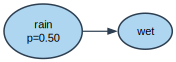

In [50]:
bn1.show_graph(show_cpt=True)

## 2. Plate — shared biased coin (!)

**Problem**: flip the *same* biased coin *m* times — each flip must be an independent random variable, yet all share the same `bias` parameter.

In λ!-calculus:
```
let bias = sample_d       in
let coin = !(case⟨bias⟩)  in   ← ! = plate (freeze)
let y1   = der coin        in   ← der = dereference (thaw)
let y2   = der coin
```

`bn.plate()` **freezes** a distribution without creating a node.  
Each call `coin()` **thaws** it and creates a new independent node.

In [51]:
bn2  = BNppl(name='SharedCoin')
bias = bn2.sample('bias', Bernoulli(0.6))

coin = bn2.plate('coin', bn2.where(bias, 0.8, 0.3))

y1 = coin()
y2 = coin()

bn2.compile()
bn2.show()


BN compiled : 3 nodes, 2 arcs, 10 CPT entries (0.0 MB)  [n_bins=10, strategy=uniform, method=midpoint]

BN compiled : 3 nodes, 2 arcs  [method=midpoint]
Nodes : ['coin_1', 'coin_2', 'bias']
Arcs  : [('bias', 'coin_1'), ('bias', 'coin_2')]


In [52]:
# Two heads observed: update our belief about the bias
p2 = bn2.query("bias", evidence={"coin_1": True, "coin_2": True})
print(f"Prior       P(bias=True) = 0.6")
print(f"Posterior   P(bias=True | y1=T, y2=T) ≈ {p2['True']:.3f}")
print(f"  → two heads → evidence strongly favours high bias")

Prior       P(bias=True) = 0.6
Posterior   P(bias=True | y1=T, y2=T) ≈ 0.914
  → two heads → evidence strongly favours high bias


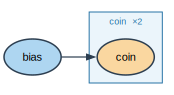

In [53]:
# Plate-derived nodes are grouped in the graph (×2 rectangle)
bn2.show_graph()

## 3. Continuous variables — automatic discretization

pyAgrum only supports discrete variables. Bnpyro automatically discretizes continuous distributions into `n_bins` equal-width intervals covering ~99% of the probability mass.

Bin probabilities are computed via the **CDF**:  `P(X in [a, b]) = F(b) − F(a)`

Supported distributions: `Normal`, `Beta`, `Gamma`, `Uniform`, `Exponential`, `LogNormal` (from `distributions.py`).

In [54]:
bn3  = BNppl(n_bins=8, name='ContinuousBN')
temp = bn3.sample('temp',  Normal(20.0, 5.0))
hum  = bn3.sample('humid', Normal(60.0, 10.0))

bn3.compile()
bn3.show()


BN compiled : 2 nodes, 0 arcs, 16 CPT entries (0.0 MB)  [n_bins=8, strategy=uniform, method=midpoint]

BN compiled : 2 nodes, 0 arcs  [method=midpoint]
Nodes : ['humid', 'temp']
Arcs  : []


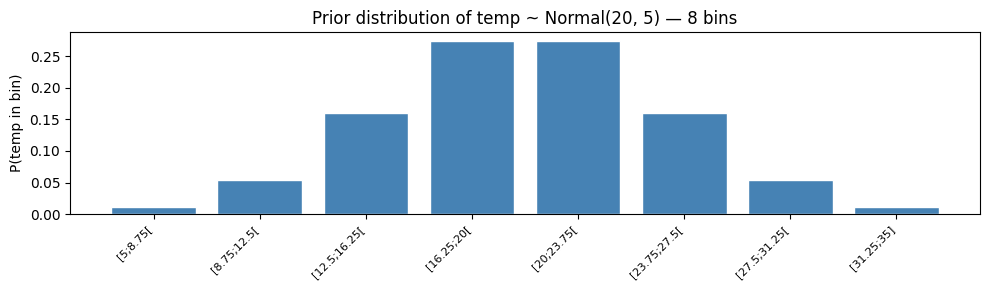

In [55]:
p3 = bn3.query("temp")

fig, ax = plt.subplots(figsize=(10, 3))
labels, values = list(p3.keys()), list(p3.values())
ax.bar(range(len(labels)), values, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("P(temp in bin)")
ax.set_title("Prior distribution of temp ~ Normal(20, 5) — 8 bins")
plt.tight_layout()
plt.show()

### Choosing `n_bins`

More bins = better approximation, but CPT size grows as $n^{k+1}$ where $k$ is the number of continuous parents.

| Situation | Recommended `n_bins` |
|---|---|
| No continuous parents | 10 – 20 |
| 1 continuous parent | 10 – 15 |
| 2 continuous parents | 8 – 10 |
| 3+ continuous parents | 5 – 8 |

**Rule of thumb**: double `n_bins` and check if inference results stabilize.

## 4. Plate — N coins sharing a bias

`bn.plate(name, dist_or_fn)` freezes a distribution. Each call `()` creates an independent node with the **same CPT** but a **distinct identity** in the BN.

`show_graph()` groups plate-derived nodes into a ×N cluster.

In [56]:
bn4  = BNppl(name='PlateBN')
bias = bn4.sample('bias', Bernoulli(0.6))

coin = bn4.plate('coin', bn4.where(bias, 0.8, 0.3))

flips = [coin() for _ in range(5)]

bn4.compile()
bn4.show()


BN compiled : 6 nodes, 5 arcs, 22 CPT entries (0.0 MB)  [n_bins=10, strategy=uniform, method=midpoint]

BN compiled : 6 nodes, 5 arcs  [method=midpoint]
Nodes : ['coin_1', 'coin_2', 'coin_5', 'coin_3', 'bias', 'coin_4']
Arcs  : [('bias', 'coin_1'), ('bias', 'coin_4'), ('bias', 'coin_3'), ('bias', 'coin_2'), ('bias', 'coin_5')]


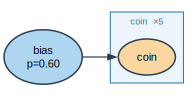

In [57]:
# Template view with plate notation
bn4.show_graph(show_cpt=True)

In [58]:
# 4 heads, 1 tail — update our belief about the bias
p4 = bn4.query('bias', evidence={
    'coin_1': True, 'coin_2': True, 'coin_3': True, 'coin_4': True,
    'coin_5': False,
})
print(f"Prior       P(bias=True) = 0.6")
print(f"Posterior   P(bias=True | 4H 1T) = {p4['True']:.3f}")
print(f"  -> four heads -> evidence shifts belief toward high bias")

Prior       P(bias=True) = 0.6
Posterior   P(bias=True | 4H 1T) = 0.956
  -> four heads -> evidence shifts belief toward high bias



## 5. Universal lambda — any parent/child type combination

To condition a node on parents of **any type** (discrete or continuous), use a **lambda**:

```python
bn.sample("x", lambda parent_val: dist.SomeDist(...), parents=[parent_node])
```

Bnpyro **probes the lambda's return type** and routes to the correct construction:
- Lambda → `Bernoulli`  → discrete binary node
- Lambda → `Categorical`→ discrete k-class node
- Lambda → anything else → continuous (discretized) node

### 5a. Continuous → Continuous : X ~ Normal(μ, 1) with μ ~ Normal(0, 1)


BN compiled : 2 nodes, 1 arcs, 42 CPT entries (0.0 MB)  [n_bins=6, strategy=uniform, method=midpoint]

BN compiled : 2 nodes, 1 arcs, 42 CPT entries (0.0 MB)  [n_bins=6, strategy=uniform, method=integration]


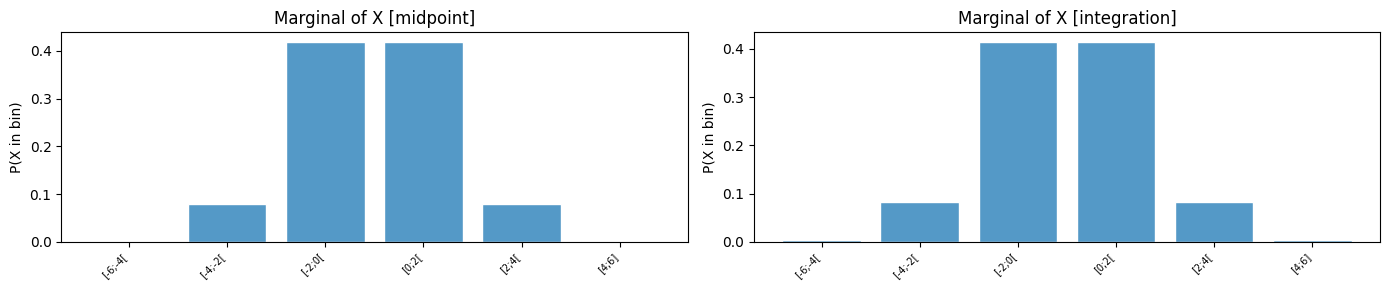

Both methods agree — INTEGRATION is more precise for coarse bins.


In [59]:
results = {}
for method in (MIDPOINT, INTEGRATION):
    bn5 = BNppl(n_bins=6, discretization_method=method)
    mu  = bn5.sample('mu', Normal(0.0, 1.0))
    x   = bn5.sample('x',  lambda m: Normal(m, 1.0), parents=[mu])
    bn5.compile()
    results[method] = bn5.query('x')

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
for ax, method in zip(axes, (MIDPOINT, INTEGRATION)):
    p = results[method]
    ax.bar(range(len(p)), list(p.values()), color='#5499C7', edgecolor='white')
    ax.set_xticks(range(len(p)))
    ax.set_xticklabels(list(p.keys()), rotation=45, ha='right', fontsize=7)
    ax.set_title(f'Marginal of X [{method}]')
    ax.set_ylabel('P(X in bin)')
plt.tight_layout()
plt.show()
print('Both methods agree — INTEGRATION is more precise for coarse bins.')

### 5b. Continuous → Bernoulli : coin ~ Bernoulli(bias) with bias ~ Uniform(0, 1)


BN compiled : 2 nodes, 1 arcs, 24 CPT entries (0.0 MB)  [n_bins=8, strategy=uniform, method=midpoint]


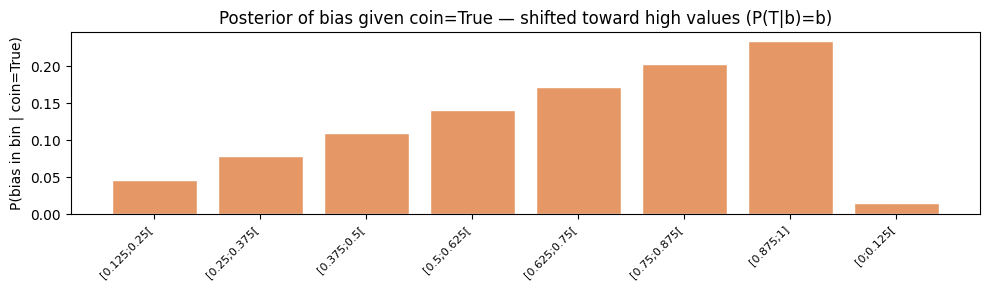

In [60]:
bn_cb = BNppl(n_bins=8)
bias  = bn_cb.sample('bias', Uniform(0.0, 1.0))
coin  = bn_cb.sample('coin',
    lambda b: Bernoulli(max(0.01, min(0.99, b))),
    parents=[bias]
)

bn_cb.compile()
p_cb = bn_cb.query('bias', evidence={'coin': True})

fig, ax = plt.subplots(figsize=(10, 3))
labels = sorted(p_cb.keys())
ax.bar(range(len(labels)), [p_cb[k] for k in labels], color='#E59866', edgecolor='white')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('P(bias in bin | coin=True)')
ax.set_title('Posterior of bias given coin=True — shifted toward high values (P(T|b)=b)')
plt.tight_layout()
plt.show()

### 5c. Categorical → Continuous : val ~ Normal(cat×5, 1) with cat ~ Categorical


BN compiled : 2 nodes, 1 arcs, 21 CPT entries (0.0 MB)  [n_bins=6, strategy=uniform, method=midpoint]


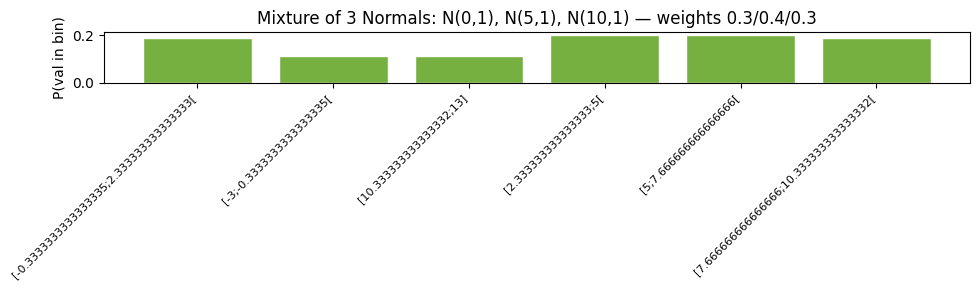

In [61]:
bn_cc = BNppl(n_bins=6)
cat   = bn_cc.sample('cat', Categorical([0.3, 0.4, 0.3]))
val   = bn_cc.sample('val',
    lambda c: Normal(c * 5.0, 1.0),
    parents=[cat]
)

bn_cc.compile()
p_cc = bn_cc.query('val')

fig, ax = plt.subplots(figsize=(10, 3))
labels = sorted(p_cc.keys())
ax.bar(range(len(labels)), [p_cc[k] for k in labels], color='#76B041', edgecolor='white')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('P(val in bin)')
ax.set_title('Mixture of 3 Normals: N(0,1), N(5,1), N(10,1) — weights 0.3/0.4/0.3')
plt.tight_layout()
plt.show()


## 6. Multi-parent discrete — nested bn.where

For a Bernoulli node conditioned on **multiple discrete parents**, nest `bn.where` calls:

```python
wet = bn.sample("wet", bn.where(rain,
    bn.where(sprinkler, 0.99, 0.90),   # rain=True branch
    bn.where(sprinkler, 0.80, 0.01),   # rain=False branch
))
```

This encodes the **Wet Grass** CPT from Darwiche (2009).


BN compiled : 3 nodes, 2 arcs, 12 CPT entries (0.0 MB)  [n_bins=10, strategy=uniform, method=midpoint]


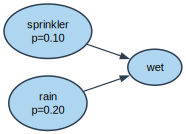

In [62]:
bn6  = BNppl(name='WetGrass')
rain = bn6.sample('rain',      Bernoulli(0.2))
spr  = bn6.sample('sprinkler', Bernoulli(0.1))
wet  = bn6.sample('wet', bn6.where(rain,
    bn6.where(spr, 0.99, 0.90),
    bn6.where(spr, 0.80, 0.01),
))

bn6.compile()
bn6.show_graph(show_cpt=True)

In [63]:
p_rain = bn6.query("rain",      evidence={"wet": True})
p_spr  = bn6.query("sprinkler", evidence={"wet": True})

print(f"P(rain=True      | wet=True) = {p_rain['True']:.3f}")
print(f"P(sprinkler=True | wet=True) = {p_spr['True']:.3f}")
print()
print("Rain is more likely than sprinkler because P(rain) > P(sprinkler).")

P(rain=True      | wet=True) = 0.719
P(sprinkler=True | wet=True) = 0.331

Rain is more likely than sprinkler because P(rain) > P(sprinkler).



## 7. Recursion — fix combinator

The **fix** (fixed-point) combinator encodes recursive programs. In λ!-calculus, a Markov chain of length n is written:

```
let chain = fix(λself. λn.
  if n=0 then sample(Bernoulli(0.5))
  else let prev = self(n-1) in sample(case⟨prev⟩(0.9, 0.1))
)
```

`bn.recurse(name, step_fn, n_steps)` unrolls the fixed point `n_steps` times:
- `step_fn(i, None)` → base case (i=0, no parent yet)
- `step_fn(i, prev)` → step case (i>0, prev = last node)
- If `step_fn` returns a callable, it is called with `parents=[prev]` (for continuous parents)

The modeled problem :  

Imagine a system that evolves over time - for example:  

A machine with two states: Working (True) or Broken (False)  
Initial state: P($X_0$ = True) = 0.5 (equilibrium)

Transition rule:  
If it is working today → there is a 90% chance that it will remain working tomorrow  
If it is broken today → there is a 10% chance that it will become working tomorrow  


BN compiled : 4 nodes, 3 arcs, 14 CPT entries (0.0 MB)  [n_bins=10, strategy=uniform, method=midpoint]

BN compiled : 4 nodes, 3 arcs  [method=midpoint]
Nodes : ['X_0', 'X_2', 'X_1', 'X_3']
Arcs  : [('X_0', 'X_1'), ('X_1', 'X_2'), ('X_2', 'X_3')]


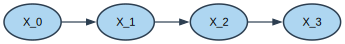

In [64]:
N    = 4
bn7a = BNppl(name='MarkovChain')
states = bn7a.recurse(
    'X',
    lambda _, prev:
        Bernoulli(0.5) if prev is None
        else bn7a.where(prev, 0.9, 0.1),
    n_steps=N,
    labels=['broken', 'working'],
)

bn7a.compile()
bn7a.show()
bn7a.show_graph()

In [65]:
p7a = bn7a.query(f'X_{N-1}', evidence={'X_0': 'working'})
print(f"P(X_{N-1}=working | X_0=working) = {p7a['working']:.3f}")
print(f"  Expected ~ 0.9^{N-1} = {0.9**(N-1):.3f}")

P(X_3=working | X_0=working) = 0.756
  Expected ~ 0.9^3 = 0.729



BN compiled : 4 nodes, 3 arcs, 200 CPT entries (0.0 MB)  [n_bins=8, strategy=uniform, method=midpoint]

BN compiled : 4 nodes, 3 arcs  [method=midpoint]
Nodes : ['pos_3', 'pos_1', 'pos_2', 'pos_0']
Arcs  : [('pos_0', 'pos_1'), ('pos_1', 'pos_2'), ('pos_2', 'pos_3')]


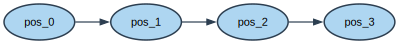

In [66]:
bn7b = BNppl(n_bins=8, name='RandomWalk')
traj = bn7b.recurse(
    'pos',
    lambda _, prev:
        Normal(0.0, 1.0) if prev is None
        else (lambda p: Normal(p, 0.5)),
    n_steps=4
)

bn7b.compile()
bn7b.show()
bn7b.show_graph()

## 8. Higher-order functions

The λ!-calculus supports **higher-order programs** — functions that take functions (or thunks) as arguments.  
In Bnpyro, Python functions over `BNNode` and `BNThunk` objects naturally encode these patterns.

### 8a. Parametric plate `!(λb. Bernoulli(b))` — plate depending on a parent

A **parametric plate** freezes a lambda + parents. Each dereference creates a new node with the same CPT.


BN compiled : 3 nodes, 2 arcs, 40 CPT entries (0.0 MB)  [n_bins=8, strategy=uniform, method=midpoint]

BN compiled : 3 nodes, 2 arcs  [method=midpoint]
Nodes : ['coin_1', 'coin_2', 'bias']
Arcs  : [('bias', 'coin_1'), ('bias', 'coin_2')]


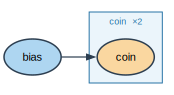

P(bias > 0.5 | 2 heads) = 0.757


In [67]:
bn8a  = BNppl(n_bins=8)
bias  = bn8a.sample('bias', Uniform(0.0, 1.0))

coin  = bn8a.plate('coin',
    lambda b: Bernoulli(max(0.01, min(0.99, b))),
    parents=[bias]
)

y1 = coin()
y2 = coin()

bn8a.compile()
bn8a.show()
bn8a.show_graph()

p8a = bn8a.query('bias', evidence={'coin_1': True, 'coin_2': True})
p_high = sum(v for k, v in p8a.items() if float(k.split(';')[0].strip('[')) > 0.5)
print(f"P(bias > 0.5 | 2 heads) = {p_high:.3f}")

### 8b. HOF taking a BNPlate — `apply_n : !A → N → Aⁿ`


BN compiled : 3 nodes, 0 arcs, 6 CPT entries (0.0 MB)  [n_bins=10, strategy=uniform, method=midpoint]

BN compiled : 3 nodes, 0 arcs  [method=midpoint]
Nodes : ['fair_2', 'fair_1', 'fair_3']
Arcs  : []


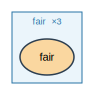

Created nodes: ['fair_1', 'fair_2', 'fair_3']


In [68]:
def apply_n(plate: BNPlate, n: int) -> list:
    """Higher-order function: dereferences a plate n times. apply_n : !A → N → Aⁿ"""
    return [plate() for _ in range(n)]

bn8b  = BNppl()
fair  = bn8b.plate('fair', Bernoulli(0.5))
flips = apply_n(fair, 3)

bn8b.compile()
bn8b.show()
bn8b.show_graph()
print(f"Created nodes: {[n.name for n in flips]}")

### 8c. Reusable BN constructor — `λsignal. sample("sensor", N(signal, 0.2))`

A Python function taking `BNNode` arguments and returning a `BNNode` is a higher-order BN constructor.


BN compiled : 3 nodes, 2 arcs, 78 CPT entries (0.0 MB)  [n_bins=6, strategy=uniform, method=midpoint]

BN compiled : 3 nodes, 2 arcs  [method=midpoint]
Nodes : ['signal', 'obs2', 'obs1']
Arcs  : [('signal', 'obs1'), ('signal', 'obs2')]


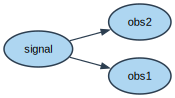

P(signal | obs1>0, obs2>0):
  [-1;0[               : 0.000
  [-2;-1[              : 0.000
  [-3;-2[              : 0.000
  [0;1[                : 0.998
  [1;2[                : 0.002
  [2;3]                : 0.000


In [69]:
def make_sensor(bn_ctx: BNppl, signal_node, name: str):
    """Reusable pattern: noisy sensor reading a continuous signal."""
    return bn_ctx.sample(name, lambda s: Normal(s, 0.2), parents=[signal_node])

bn8c   = BNppl(n_bins=6)
signal = bn8c.sample('signal', Normal(0.0, 1.0))
obs1   = make_sensor(bn8c, signal, 'obs1')
obs2   = make_sensor(bn8c, signal, 'obs2')

bn8c.compile()
bn8c.show()
bn8c.show_graph()

p8c = bn8c.query('signal', evidence={'obs1': 3, 'obs2': 3})
print('P(signal | obs1>0, obs2>0):')
for k, v in sorted(p8c.items()):
    print(f"  {k:20s} : {v:.3f}")

## 9. Multi-parent conditioning — Python as λ!-calculus

In λ!-calculus, the **tensor product** `L ⊗ K` represents passing multiple values together. In Python, this is just a tuple — no special wrapper needed.

A Python function taking multiple `BNNode` arguments and returning a `BNNode` directly encodes higher-order multi-parent conditioning.


BN compiled : 3 nodes, 2 arcs, 12 CPT entries (0.0 MB)  [n_bins=10, strategy=uniform, method=midpoint]

BN compiled : 3 nodes, 2 arcs  [method=midpoint]
Nodes : ['wind', 'wet', 'rain']
Arcs  : [('rain', 'wet'), ('wind', 'wet')]


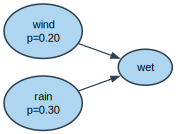

In [70]:
bn9  = BNppl(name='RainWindWet')
rain = bn9.sample('rain', Bernoulli(0.3))
wind = bn9.sample('wind', Bernoulli(0.2))

weather = (rain, wind)

r, w = weather
wet = bn9.sample('wet', bn9.where(r,
    bn9.where(w, 0.99, 0.90),
    bn9.where(w, 0.70, 0.01),
))

bn9.compile()
bn9.show()
bn9.show_graph(show_cpt=True)

In [71]:
p9 = bn9.query('rain', evidence={'wet': True})
print(f"P(rain=True | wet=True) = {p9['True']:.3f}")

P(rain=True | wet=True) = 0.727


## 10. Exact inference — correctness verification

Unlike MCMC (which gives approximate results), Bnpyro uses **Variable Elimination** for exact inference. With the right choice of parameters, results are analytically exact with no rounding.

**Example**: `P(rain=T) = 0.5`, `P(wet=T|rain=T) = 0.9`, `P(wet=T|rain=F) = 0.1`

The posterior is:
$$P(\text{rain}=T \mid \text{wet}=T) = \frac{0.9 \times 0.5}{0.9 \times 0.5 + 0.1 \times 0.5} = \frac{0.9}{1.0} = 0.9$$

An exact integer-like result — no approximation.

In [72]:
bn10 = BNppl(name='ExactInference')
rain = bn10.sample('rain', Bernoulli(0.5))
wet  = bn10.sample('wet',  bn10.where(rain, 0.9, 0.1))

bn10.compile()
p = bn10.query('rain', evidence={'wet': True})
print(f"P(rain=True  | wet=True) = {p['True']}")   # exact: 0.9
print(f"P(rain=False | wet=True) = {p['False']}")  # exact: 0.1
print()
print(f"Analytical: 0.9*0.5 / (0.9*0.5 + 0.1*0.5) = {0.9*0.5 / (0.9*0.5 + 0.1*0.5)}")


BN compiled : 2 nodes, 1 arcs, 6 CPT entries (0.0 MB)  [n_bins=10, strategy=uniform, method=midpoint]
P(rain=True  | wet=True) = 0.9
P(rain=False | wet=True) = 0.1

Analytical: 0.9*0.5 / (0.9*0.5 + 0.1*0.5) = 0.9
